In [1]:
import pandas as pd
import mat73
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ranksums, sem
import seaborn as sns
from itertools import combinations


In [2]:
subj = 'pdnm091'

mat_path1 = r"C:\Users\fkamdar\Desktop\repos\data\pd_beh_data\Results_PDNM091_S1_C1_B2_2026-04-13.mat"
condition1 = 'ONmed_ONstimDorsal'  # ses01
data1 = mat73.loadmat(mat_path1)

mat_path2 = r"C:\Users\fkamdar\Desktop\repos\data\pd_beh_data\Results_PDNM091_S2_C2_B2_2026-04-27.mat"
condition2 = 'OFFmed_ONstimDorsal'  # ses02
data2 = mat73.loadmat(mat_path2)

mat_path3 = r"C:\Users\fkamdar\Desktop\repos\data\pd_beh_data\Results_PDNM091_S3_C3_B2_2026-06-30.mat"
condition3 = 'OFFmed_ONstimVentral'  # ses03
data3 = mat73.loadmat(mat_path3)

manifest_ses01 = pd.read_csv(r"C:\Users\fkamdar\Desktop\repos\data\pd_beh_data\PDNM091_session_1.csv")
manifest_ses02 = pd.read_csv(r"C:\Users\fkamdar\Desktop\repos\data\pd_beh_data\PDNM091_session_2.csv")
manifest_ses03 = pd.read_csv(r"C:\Users\fkamdar\Desktop\repos\data\pd_beh_data\PDNM091_session_3.csv")

In [3]:
# Session 1
results_pdnm091_ses01 = data1['Results']  # adjust key name if needed
trials_pdnm091_ses01 = pd.DataFrame(results_pdnm091_ses01['Trials'])
trials_pdnm091_ses01['ImageIndex'] = trials_pdnm091_ses01['ImageIndex'].astype(int)
merged_df_ses01 = pd.merge(trials_pdnm091_ses01, manifest_ses01, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses01.drop(columns=['trial'], inplace=True)
merged_df_ses01.drop(columns=['condition'], inplace=True)
merged_df_ses01 = merged_df_ses01.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction'
})

# Session 2
results_pdnm091_ses02 = data2['Results']  # adjust key name if needed
trials_pdnm091_ses02 = pd.DataFrame(results_pdnm091_ses02['Trials'])
trials_pdnm091_ses02['ImageIndex'] = trials_pdnm091_ses02['ImageIndex'].astype(int)
merged_df_ses02 = pd.merge(trials_pdnm091_ses02, manifest_ses02, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses02.drop(columns=['trial'], inplace=True)
merged_df_ses02.drop(columns=['condition'], inplace=True)
merged_df_ses02 = merged_df_ses02.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction'
})

# Session 3
results_pdnm091_ses03 = data3['Results']  # adjust key name if needed
trials_pdnm091_ses03 = pd.DataFrame(results_pdnm091_ses03['Trials'])
trials_pdnm091_ses03['ImageIndex'] = trials_pdnm091_ses03['ImageIndex'].astype(int)
merged_df_ses03 = pd.merge(trials_pdnm091_ses03, manifest_ses03, left_on='ImageIndex', right_on='trial', how='left')
merged_df_ses03.drop(columns=['trial'], inplace=True)
merged_df_ses03.drop(columns=['condition'], inplace=True)
merged_df_ses03 = merged_df_ses03.rename(columns={
    'Valence_x': 'participant_rating',
    'Valence_y': 'normative_rating',
    'Condition': 'instruction'
})


In [ ]:
print("Session 1 DataFrame:")
print(merged_df_ses01.head())

In [4]:
def plot_valence_vs_normative(merged_df, condition, subj, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    normative_ratings = merged_df['normative_rating'].values
    valence_ratings = merged_df['participant_rating'].values
    normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
    valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)

    mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
    num_valence_nans = np.isnan(valence_ratings).sum()
    norm_vals_clean = normative_ratings[mask]
    valence_clean = valence_ratings[mask]

    ax.scatter(norm_vals_clean, valence_clean, alpha=0.7)

    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)

    ax.plot(x_fit, fit_fn(x_fit), color='red', linewidth=2, label='Linear fit')
    ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
    ax.legend(loc='upper left', bbox_to_anchor=(0, 1))
    ax.set_xlabel('Normative Ratings')
    ax.set_ylabel('Valence Ratings')
    ax.set_title(f'{condition} {subj} Valence Ratings')
    ax.set_xticks(np.arange(1, 10, 1))
    ax.set_yticks(np.arange(1, 10, 1))
    ax.set_xlim(1, 9)
    ax.set_ylim(0, 10)
    #ax.text(0.75, 0.15, f'Number of NaNs: {num_valence_nans}', fontsize=10, color='red', transform=ax.transAxes)
    #num_trials = len(merged_df)
    #ax.text(0.75, 0.15, f'Number of Trials: {num_trials}', fontsize=10, color='red', transform=ax.transAxes)
    ax.grid(True)

    return ax

<Axes: title={'center': 'OFFmed_ONstimVentral pdnm091 Valence Ratings'}, xlabel='Normative Ratings', ylabel='Valence Ratings'>

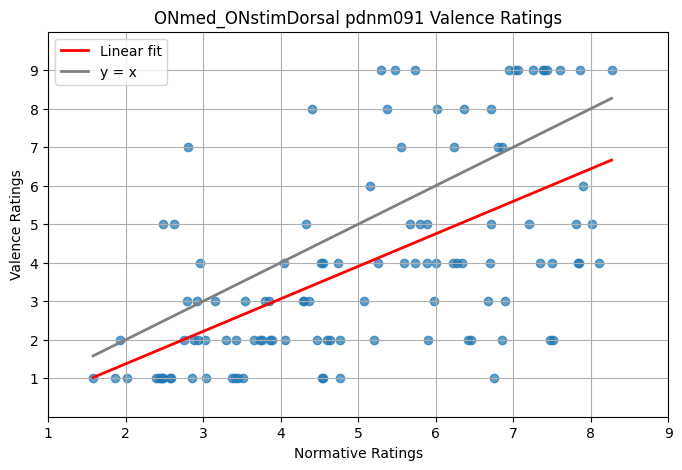

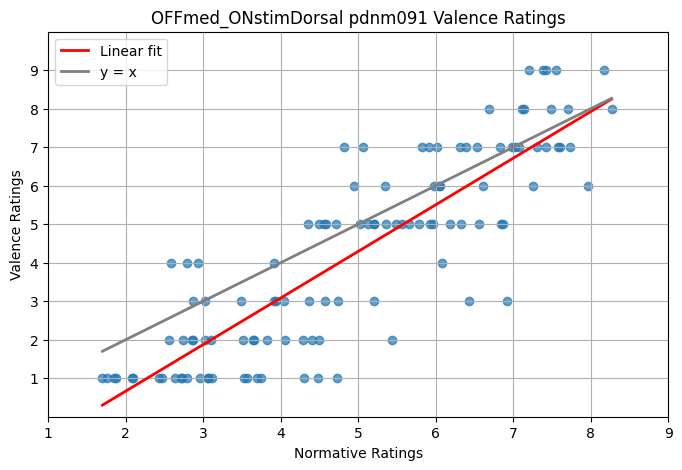

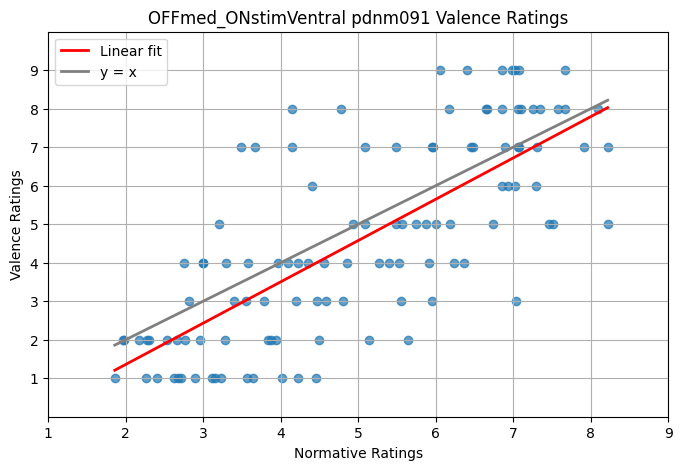

In [5]:
# Fig 1 - ALL ratings for all 3 sessions
plot_valence_vs_normative(merged_df_ses01, condition1, subj)
plot_valence_vs_normative(merged_df_ses02, condition2, subj)
plot_valence_vs_normative(merged_df_ses03, condition3, subj)

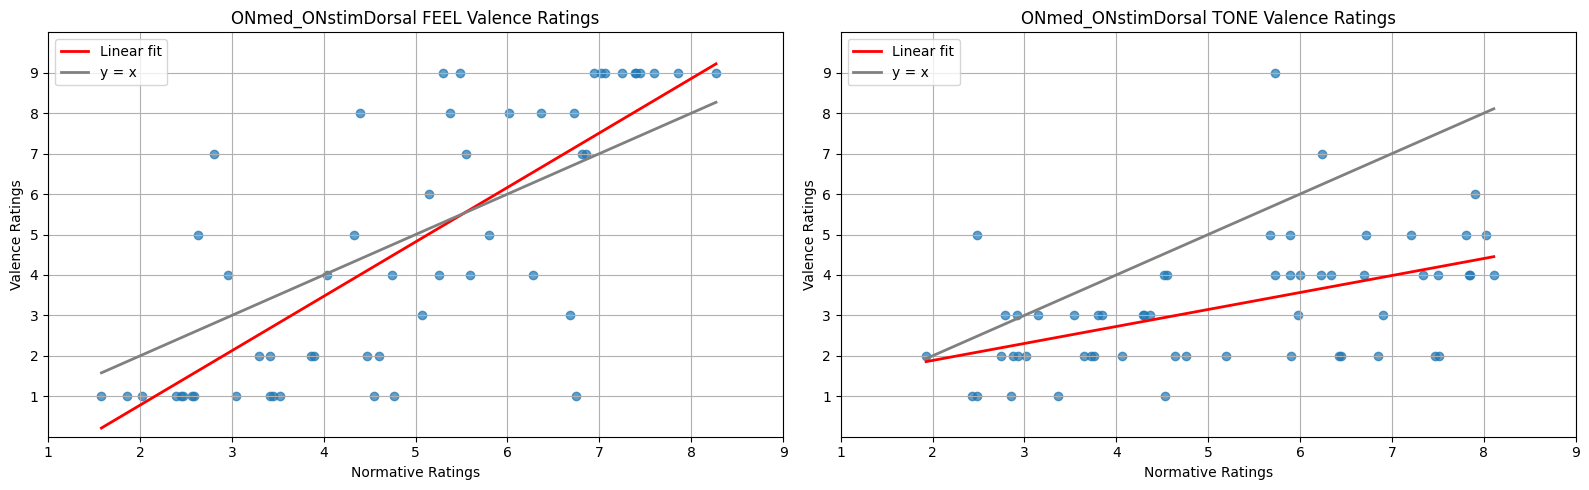

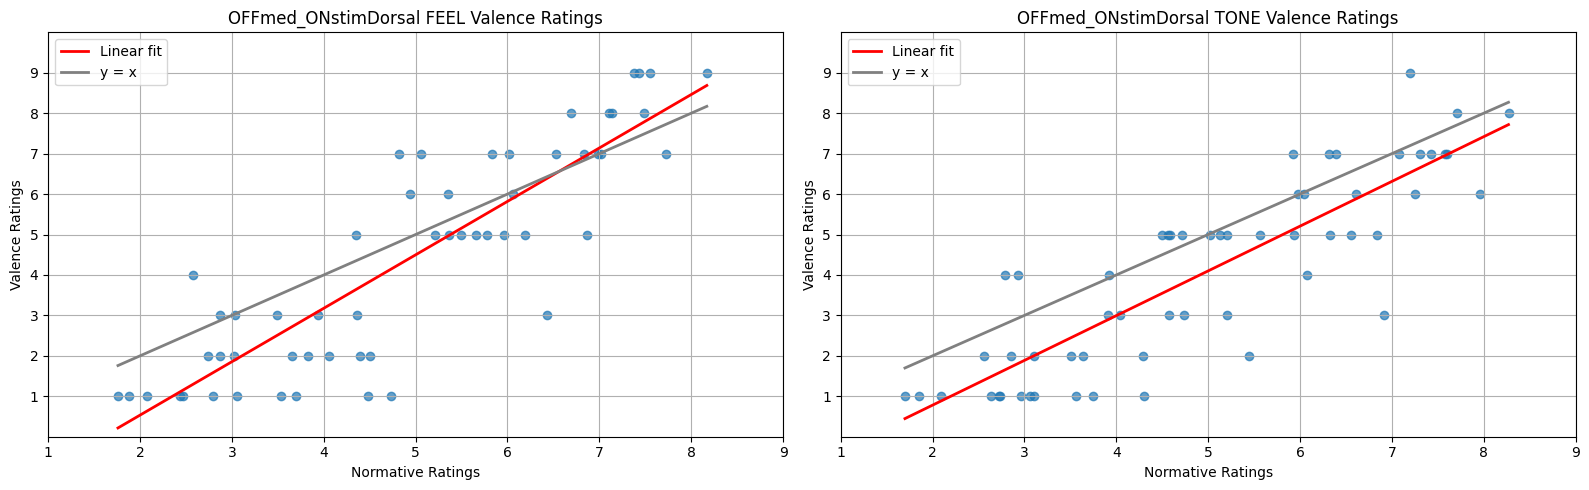

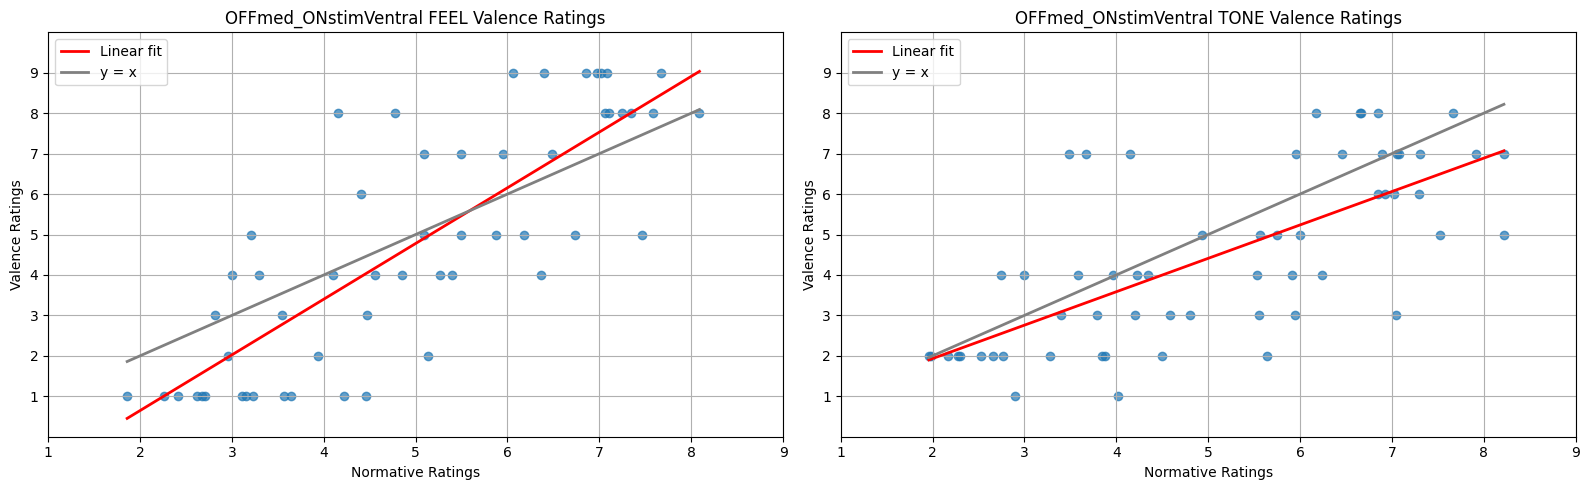

In [6]:
sessions = [
    (condition1, merged_df_ses01),
    (condition2, merged_df_ses02),
    (condition3, merged_df_ses03),
]

for sess_label, df in sessions:
    feel_trials = df[df['instruction'] == 'FEEL']
    tone_trials = df[df['instruction'] == 'TONE']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    plot_valence_vs_normative(feel_trials,sess_label, 'FEEL', ax=axes[0])
    plot_valence_vs_normative(tone_trials,  sess_label,'TONE',  ax=axes[1])
    plt.tight_layout()
    plt.show()

In [7]:
cue_types = {'FEEL', 'TONE'}
cue_types = list({'FEEL', 'TONE'})
print(cue_types[0])
print(cue_types[1])

TONE
FEEL


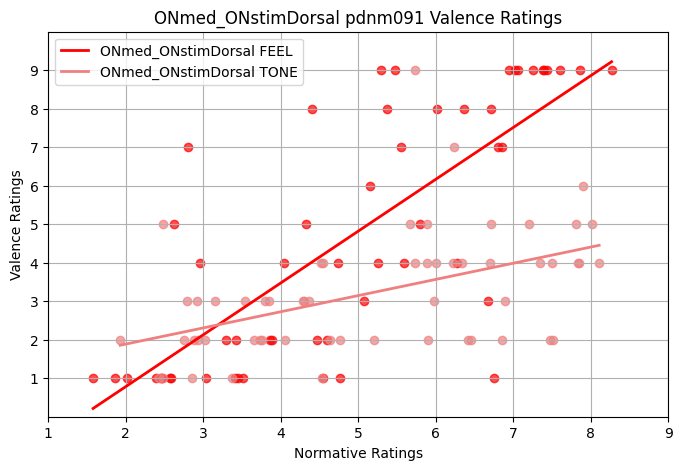

In [8]:
feel_trials = merged_df_ses01[merged_df_ses01['instruction'] == cue_types[1]]
tone_trials = merged_df_ses01[merged_df_ses01['instruction'] == cue_types[0]]

# Feel trials
normative_ratings = feel_trials['normative_rating'].values
valence_ratings = feel_trials['participant_rating'].values
normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)
mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
num_valence_nans = np.isnan(valence_ratings).sum()
norm_vals_clean = normative_ratings[mask]
valence_clean = valence_ratings[mask]

# Tone trials
tone_normative_ratings = tone_trials['normative_rating'].values
tone_valence_ratings = tone_trials['participant_rating'].values
tone_normative_ratings = pd.to_numeric(pd.Series(tone_normative_ratings), errors='coerce').to_numpy(dtype=float)
tone_valence_ratings = pd.to_numeric(pd.Series(tone_valence_ratings), errors='coerce').to_numpy(dtype=float)
tone_mask = ~np.isnan(tone_normative_ratings) & ~np.isnan(tone_valence_ratings)
tone_num_valence_nans = np.isnan(tone_valence_ratings).sum()
tone_norm_vals_clean = tone_normative_ratings[tone_mask]
tone_valence_clean = tone_valence_ratings[tone_mask]

fig, ax = plt.subplots(figsize=(8, 5))

# Feel: red
ax.scatter(norm_vals_clean, valence_clean, alpha=0.7, color='red')
coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
fit_fn = np.poly1d(coeffs)
x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)
ax.plot(x_fit, fit_fn(x_fit), color='red', linewidth=2, label=f'{condition1} {cue_types[1]}')

# Tone: light red
ax.scatter(tone_norm_vals_clean, tone_valence_clean, alpha=0.7, color='lightcoral')
tone_coeffs = np.polyfit(tone_norm_vals_clean, tone_valence_clean, 1)
tone_fit_fn = np.poly1d(tone_coeffs)
tone_x_fit = np.linspace(tone_norm_vals_clean.min(), tone_norm_vals_clean.max(), 100)
ax.plot(tone_x_fit, tone_fit_fn(tone_x_fit), color='lightcoral', linewidth=2, label=f'{condition1} {cue_types[0]}')

#ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
ax.legend(loc='upper left', bbox_to_anchor=(0, 1))
ax.set_xlabel('Normative Ratings')
ax.set_ylabel('Valence Ratings')
ax.set_title(f'{condition1} {subj} Valence Ratings')
ax.set_xticks(np.arange(1, 10, 1))
ax.set_yticks(np.arange(1, 10, 1))
ax.set_xlim(1, 9)
ax.set_ylim(0, 10)
#ax.text(0.75, 0.15, f'Number of NaNs: {num_valence_nans}', fontsize=10, color='red', transform=ax.transAxes)
#num_trials = len(merged_df)
#ax.text(0.75, 0.15, f'Number of Trials: {num_trials}', fontsize=10, color='red', transform=ax.transAxes)
ax.grid(True)

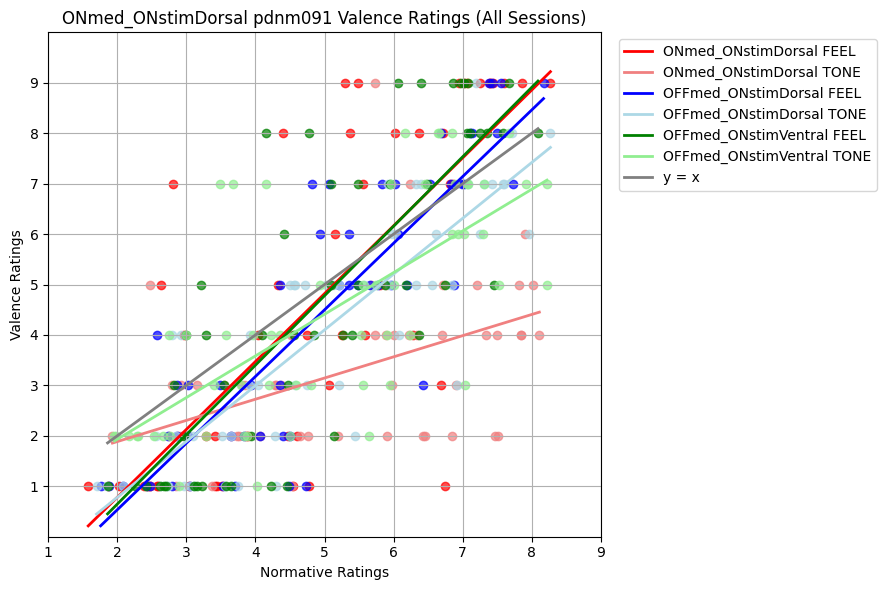

In [9]:
# Config: session dataframes, labels, and color pairs (feel color, tone color)
session_dfs = [merged_df_ses01, merged_df_ses02, merged_df_ses03]
condition_labels = [condition1, condition2, condition3]
session_colors = [
    ('red', 'lightcoral'),
    ('blue', 'lightblue'),
    ('green', 'lightgreen'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for i in range(len(session_dfs)):
    merged_df = session_dfs[i]
    condition_label = condition_labels[i]
    feel_color, tone_color = session_colors[i]

    feel_trials = merged_df[merged_df['instruction'] == cue_types[1]]
    tone_trials = merged_df[merged_df['instruction'] == cue_types[0]]

    # Feel trials
    normative_ratings = feel_trials['normative_rating'].values
    valence_ratings = feel_trials['participant_rating'].values
    normative_ratings = pd.to_numeric(pd.Series(normative_ratings), errors='coerce').to_numpy(dtype=float)
    valence_ratings = pd.to_numeric(pd.Series(valence_ratings), errors='coerce').to_numpy(dtype=float)
    mask = ~np.isnan(normative_ratings) & ~np.isnan(valence_ratings)
    norm_vals_clean = normative_ratings[mask]
    valence_clean = valence_ratings[mask]

    # Tone trials
    tone_normative_ratings = tone_trials['normative_rating'].values
    tone_valence_ratings = tone_trials['participant_rating'].values
    tone_normative_ratings = pd.to_numeric(pd.Series(tone_normative_ratings), errors='coerce').to_numpy(dtype=float)
    tone_valence_ratings = pd.to_numeric(pd.Series(tone_valence_ratings), errors='coerce').to_numpy(dtype=float)
    tone_mask = ~np.isnan(tone_normative_ratings) & ~np.isnan(tone_valence_ratings)
    tone_norm_vals_clean = tone_normative_ratings[tone_mask]
    tone_valence_clean = tone_valence_ratings[tone_mask]

    # Feel
    ax.scatter(norm_vals_clean, valence_clean, alpha=0.7, color=feel_color)
    coeffs = np.polyfit(norm_vals_clean, valence_clean, 1)
    fit_fn = np.poly1d(coeffs)
    x_fit = np.linspace(norm_vals_clean.min(), norm_vals_clean.max(), 100)
    ax.plot(x_fit, fit_fn(x_fit), color=feel_color, linewidth=2, label=f'{condition_label} {cue_types[1]}')

    # Tone
    ax.scatter(tone_norm_vals_clean, tone_valence_clean, alpha=0.7, color=tone_color)
    tone_coeffs = np.polyfit(tone_norm_vals_clean, tone_valence_clean, 1)
    tone_fit_fn = np.poly1d(tone_coeffs)
    tone_x_fit = np.linspace(tone_norm_vals_clean.min(), tone_norm_vals_clean.max(), 100)
    ax.plot(tone_x_fit, tone_fit_fn(tone_x_fit), color=tone_color, linewidth=2, label=f'{condition_label} {cue_types[0]}')

ax.plot(x_fit, x_fit, color='gray', linestyle='-', linewidth=2, label='y = x')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlabel('Normative Ratings')
ax.set_ylabel('Valence Ratings')
ax.set_title(f'{condition1} {subj} Valence Ratings (All Sessions)')
ax.set_xticks(np.arange(1, 10, 1))
ax.set_yticks(np.arange(1, 10, 1))
ax.set_xlim(1, 9)
ax.set_ylim(0, 10)
ax.grid(True)

plt.tight_layout()

In [ ]:
#NEXT TIME: LINEAR MIXED EFFECTS MODEL
# model stim condition and cue type

In [10]:
# plot by cue for all 3 sessions
print(merged_df_ses03.head())


  instruction      CueText  ImageIndex          RT_Valence participant_rating  \
0        FEEL  Feel freely           1   1.305865400005132                7.0   
1        FEEL  Feel freely           2   1.889381100423634                2.0   
2        TONE    Tone down           3  1.5746960998512805                4.0   
3        FEEL  Feel freely           4   0.454309499822557                4.0   
4        TONE    Tone down           5   1.680800300091505                5.0   

              ID           filename Category  normative_rating val_bin  
0  Animals_097_h  Animals_097_h.jpg  Animals              6.48     6-7  
1  Animals_014_h  Animals_014_h.jpg  Animals              5.14     5-6  
2    Faces_299_h    Faces_299_h.jpg    Faces              4.35     4-5  
3  Objects_179_h  Objects_179_h.jpg  Objects              4.85     4-5  
4  Objects_297_h  Objects_297_h.jpg  Objects              6.00     5-6  


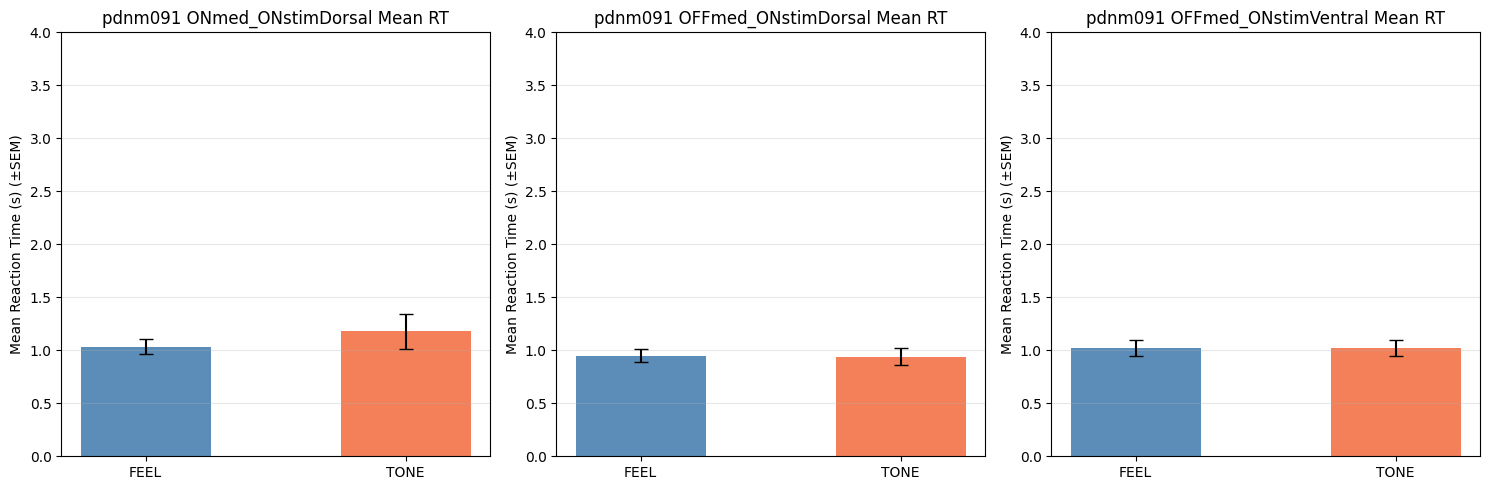

In [11]:
# plot mean +- sem reaction times for all feel and tone trials for all 3 sessions
mean_rt_feel_ses01 = merged_df_ses01[merged_df_ses01['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses01 = merged_df_ses01[merged_df_ses01['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses02 = merged_df_ses02[merged_df_ses02['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses02 = merged_df_ses02[merged_df_ses02['instruction'] == 'TONE']['RT_Valence'].mean()
mean_rt_feel_ses03 = merged_df_ses03[merged_df_ses03['instruction'] == 'FEEL']['RT_Valence'].mean()
mean_rt_tone_ses03 = merged_df_ses03[merged_df_ses03['instruction'] == 'TONE']['RT_Valence'].mean()


def plot_rt_bar(merged_df, sess_label, ax):
    feel_rt = merged_df[merged_df['instruction'] == 'FEEL']['RT_Valence'].dropna()
    tone_rt = merged_df[merged_df['instruction'] == 'TONE']['RT_Valence'].dropna()

    means = [feel_rt.mean(), tone_rt.mean()]
    sems = [sem(feel_rt), sem(tone_rt)]

    ax.bar(['FEEL', 'TONE'], means, yerr=sems, capsize=5,
           color=['#5b8db8', '#f4805a'], width=0.5)

    ax.set_ylim(0, 4)
    ax.set_title(f'{subj} {sess_label} Mean RT')
    ax.set_ylabel('Mean Reaction Time (s) (±SEM)')
    ax.grid(True, axis='y', alpha=0.3)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sessions = [
    (condition1, merged_df_ses01),
    (condition2, merged_df_ses02),
    (condition3, merged_df_ses03),
]

for (sess_label, df), ax in zip(sessions, axes):
    plot_rt_bar(df, sess_label, ax)

plt.tight_layout()
plt.show()


In [12]:
# **BINNING**

# Bin normative ratings into negative / neutral / positive
def bin_valence(rating):
    if rating <= 3:
        return 'negative'
    elif rating <= 6:
        return 'neutral'
    else:
        return 'positive'

merged_df_ses01['valence_bin'] = merged_df_ses01['normative_rating'].apply(bin_valence)
merged_df_ses02['valence_bin'] = merged_df_ses02['normative_rating'].apply(bin_valence)
merged_df_ses03['valence_bin'] = merged_df_ses03['normative_rating'].apply(bin_valence)

print(merged_df_ses01['valence_bin'].value_counts())



valence_bin
neutral     52
positive    38
negative    22
Name: count, dtype: int64


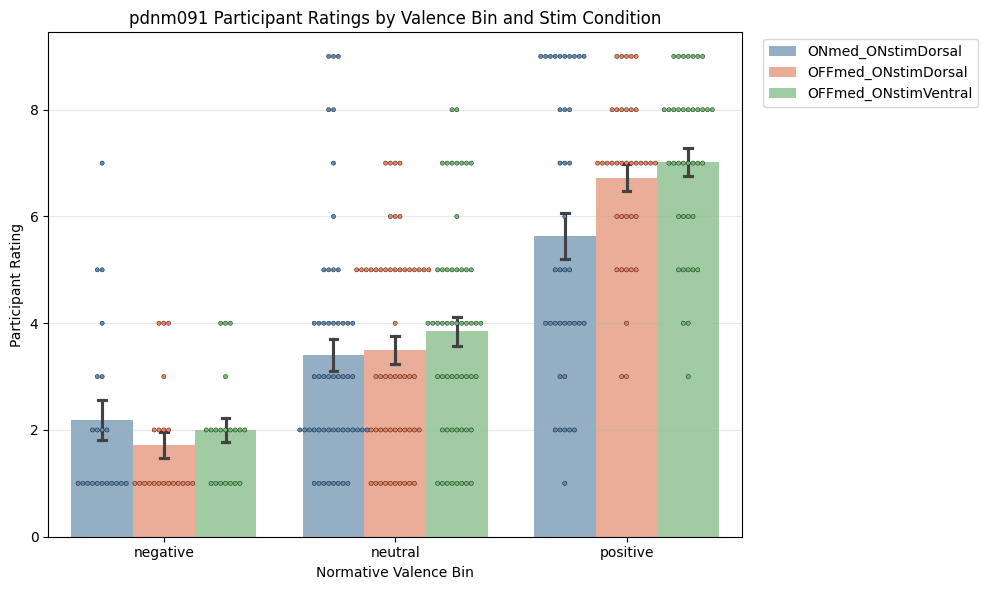

In [13]:
# Combine all sessions into one long dataframe for plotting
plot_df = pd.concat([
    merged_df_ses01.assign(condition=condition1),
    merged_df_ses02.assign(condition=condition2),
    merged_df_ses03.assign(condition=condition3),
], ignore_index=True)

plot_df['participant_rating'] = plot_df['participant_rating'].apply(
    lambda v: v.item() if isinstance(v, np.ndarray) else v
)
plot_df = plot_df.dropna(subset=['participant_rating', 'valence_bin'])

bin_labels = ['negative', 'neutral', 'positive']
condition_order = [condition1, condition2, condition3]
condition_colors = ['#5b8db8', '#f4805a', '#6fbf73']

fig, ax = plt.subplots(figsize=(10, 6))

# Bars: mean +- SEM
sns.barplot(
    data=plot_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)

# Swarm: individual points, dodged to match bar positions
sns.swarmplot(
    data=plot_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

# Remove duplicate legend entries (bar + swarm both add one)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Participant Rating')
ax.set_title(f'{subj} Participant Ratings by Valence Bin and Stim Condition')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
results = []

for b in bin_labels:
    bin_df = plot_df[plot_df['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        results.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

results_df = pd.DataFrame(results)
print(results_df)

  valence_bin          condition_1           condition_2  n1  n2  statistic  \
0    negative   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  21  21   0.716939   
1    negative   ONmed_ONstimDorsal  OFFmed_ONstimVentral  21  20  -0.365148   
2    negative  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  21  20  -1.212814   
3     neutral   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  52  54  -0.638295   
4     neutral   ONmed_ONstimDorsal  OFFmed_ONstimVentral  52  54  -1.472503   
5     neutral  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  54  54  -0.728118   
6    positive   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  38  37  -1.647865   
7    positive   ONmed_ONstimDorsal  OFFmed_ONstimVentral  38  38  -2.093325   
8    positive  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  37  38  -0.943151   

    p_value stars  
0  0.473412        
1  0.715001        
2  0.225201        
3  0.523282        
4  0.140885        
5  0.466541        
6  0.099380        
7  0.036320     *  
8  0.345604        


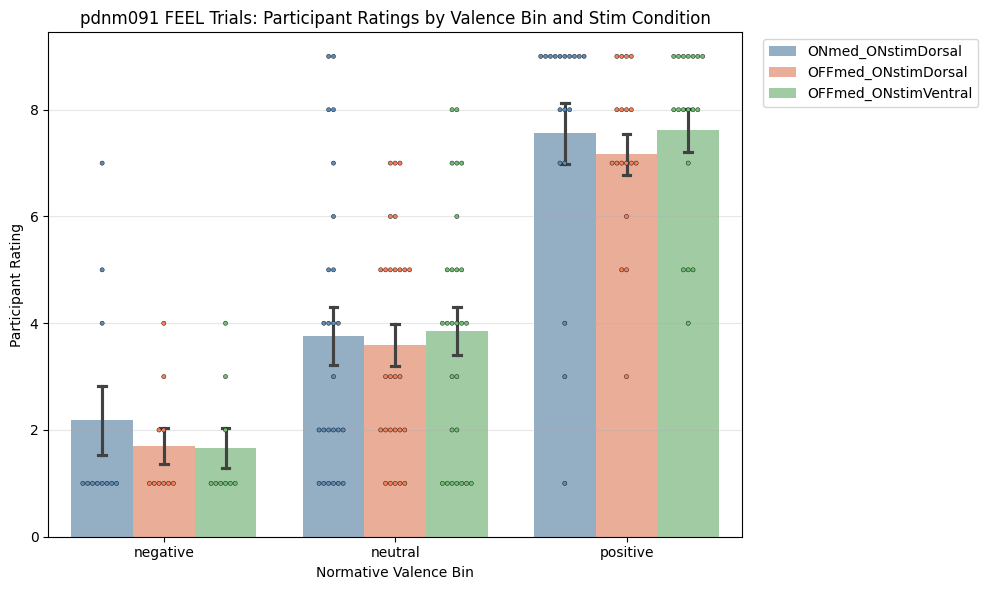

In [15]:
# Filter to only FEEL trials
feel_df = plot_df[plot_df['instruction'] == 'FEEL']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=feel_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)

sns.swarmplot(
    data=feel_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Participant Rating')
ax.set_title(f'{subj} FEEL Trials: Participant Ratings by Valence Bin and Stim Condition')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
feel_results = []

for b in bin_labels:
    bin_df = feel_df[feel_df['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        feel_results.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

feel_results_df = pd.DataFrame(feel_results)
print(feel_results_df)

  valence_bin          condition_1           condition_2  n1  n2  statistic  \
0    negative   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  11  10  -0.105627   
1    negative   ONmed_ONstimDorsal  OFFmed_ONstimVentral  11   9   0.075974   
2    negative  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  10   9   0.163299   
3     neutral   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  25  27  -0.146518   
4     neutral   ONmed_ONstimDorsal  OFFmed_ONstimVentral  25  27  -0.247249   
5     neutral  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  27  27  -0.216250   
6    positive   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  18  18   1.566111   
7    positive   ONmed_ONstimDorsal  OFFmed_ONstimVentral  18  18   0.522037   
8    positive  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  18  18  -1.138990   

    p_value stars  
0  0.915878        
1  0.939440        
2  0.870283        
3  0.883513        
4  0.804716        
5  0.828793        
6  0.117323        
7  0.601645        
8  0.254707        


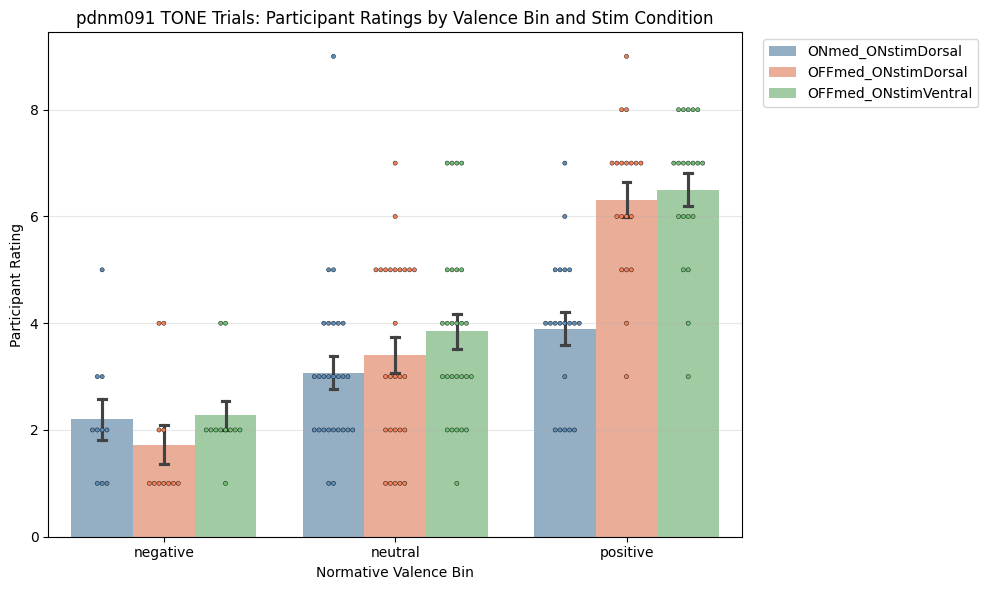

In [17]:
# Filter to only TONE trials
tone_df = plot_df[plot_df['instruction'] == 'TONE']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=tone_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)

sns.swarmplot(
    data=tone_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Participant Rating')
ax.set_title(f'{subj} TONE Trials: Participant Ratings by Valence Bin and Stim Condition')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
tone_results = []

for b in bin_labels:
    bin_df = tone_df[tone_df['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        tone_results.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

tone_results_df = pd.DataFrame(tone_results)
print(tone_results_df)

  valence_bin          condition_1           condition_2  n1  n2  statistic  \
0    negative   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  10  11   1.161895   
1    negative   ONmed_ONstimDorsal  OFFmed_ONstimVentral  10  11  -0.316880   
2    negative  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  11  11  -1.772955   
3     neutral   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  27  27  -0.804449   
4     neutral   ONmed_ONstimDorsal  OFFmed_ONstimVentral  27  27  -1.851097   
5     neutral  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  27  27  -0.761199   
6    positive   ONmed_ONstimDorsal   OFFmed_ONstimDorsal  20  19  -4.046051   
7    positive   ONmed_ONstimDorsal  OFFmed_ONstimVentral  20  20  -4.273914   
8    positive  OFFmed_ONstimDorsal  OFFmed_ONstimVentral  19  20  -0.547903   

    p_value stars  
0  0.245278        
1  0.751334        
2  0.076236        
3  0.421138        
4  0.064156        
5  0.446538        
6  0.000052   ***  
7  0.000019   ***  
8  0.583759        


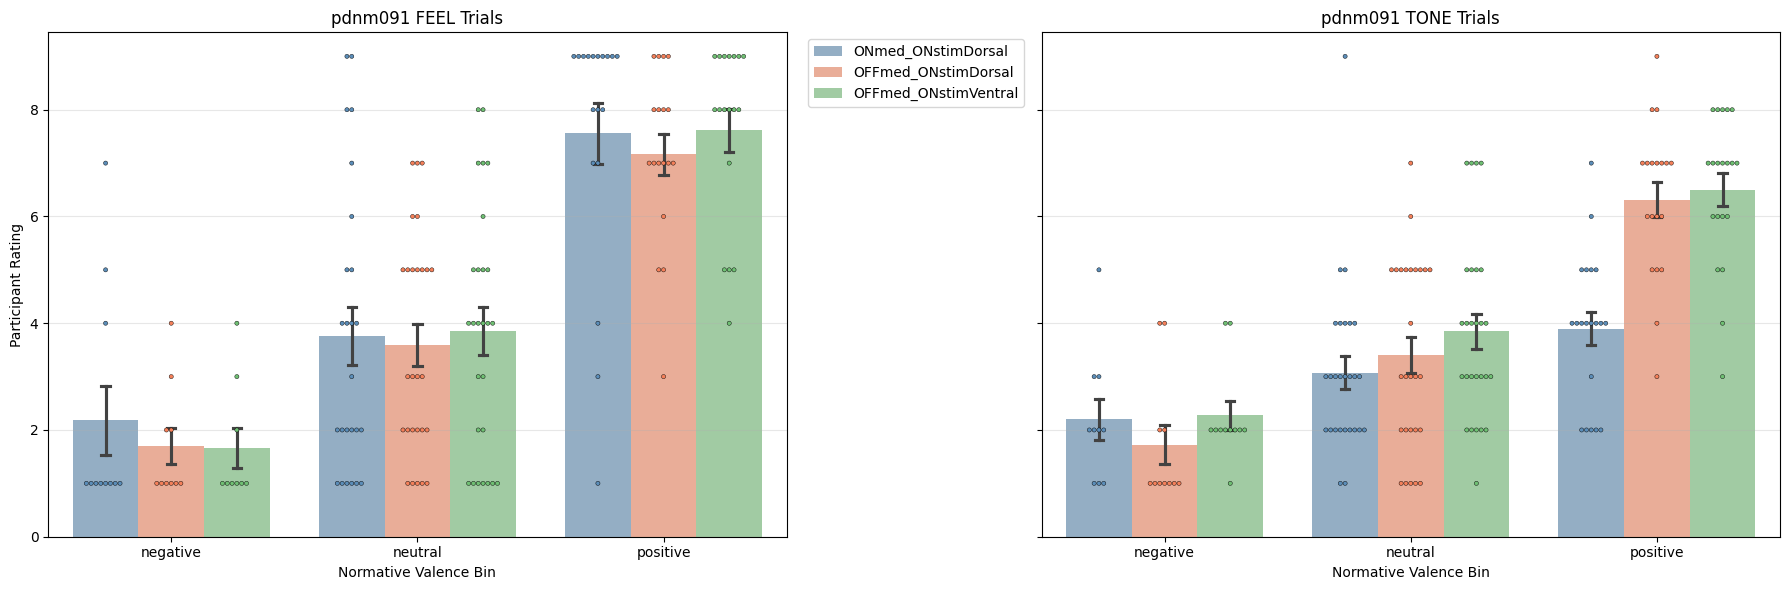

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.barplot(
    data=feel_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[0]
)
sns.swarmplot(
    data=feel_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[0]
)
axes[0].set_title(f'{subj} FEEL Trials')
axes[0].set_xlabel('Normative Valence Bin')
axes[0].set_ylabel('Participant Rating')
axes[0].grid(True, axis='y', alpha=0.3)

sns.barplot(
    data=tone_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[1]
)
sns.swarmplot(
    data=tone_df, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[1]
)
axes[1].set_title(f'{subj} TONE Trials')
axes[1].set_xlabel('Normative Valence Bin')
axes[1].set_ylabel('')
axes[1].grid(True, axis='y', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(condition_order)], labels[:len(condition_order)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

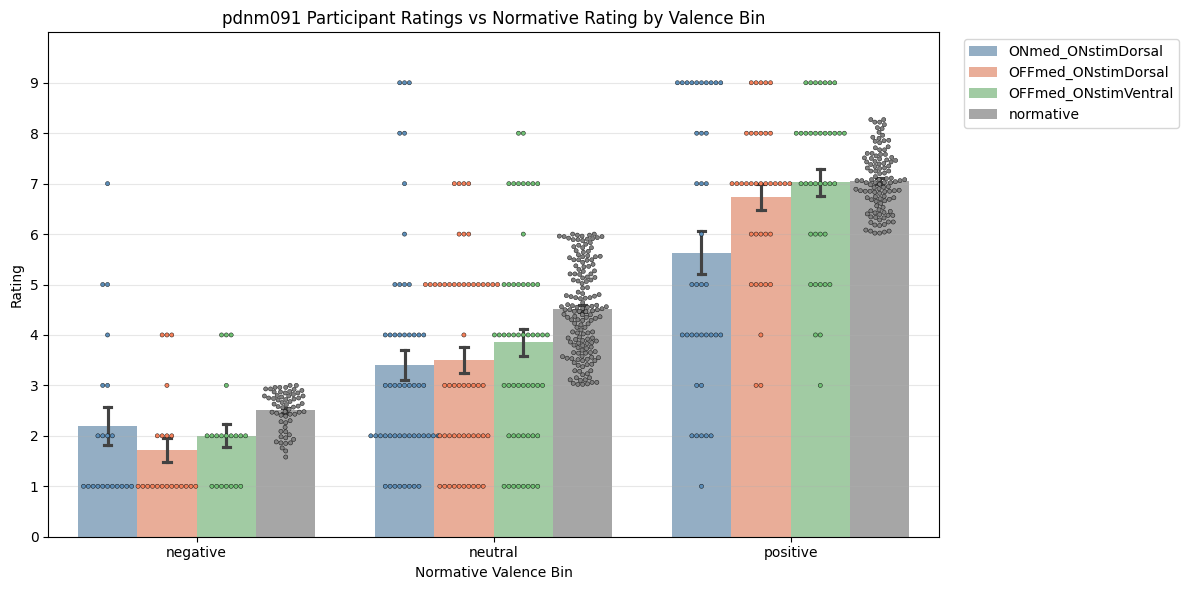

In [20]:
# Build a "normative" pseudo-condition using the normative_rating column,
# so it can sit alongside the 3 stim conditions as a 4th bar

normative_df = plot_df[['valence_bin', 'normative_rating']].copy()
normative_df = normative_df.rename(columns={'normative_rating': 'participant_rating'})
normative_df['condition'] = 'normative'

plot_df_with_norm = pd.concat([
    plot_df[['valence_bin', 'condition', 'participant_rating']],
    normative_df
], ignore_index=True)

condition_order_with_norm = condition_order + ['normative']
condition_colors_with_norm = condition_colors + ['grey']

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_ylim(0, 10)
ax.set_yticks(np.arange(0, 10, 1))

sns.barplot(
    data=plot_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)

sns.swarmplot(
    data=plot_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order_with_norm)], labels[:len(condition_order_with_norm)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Rating')
ax.set_title(f'{subj} Participant Ratings vs Normative Rating by Valence Bin')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
results_with_norm = []

for b in bin_labels:
    bin_df = plot_df_with_norm[plot_df_with_norm['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order_with_norm, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        results_with_norm.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

results_with_norm_df = pd.DataFrame(results_with_norm)
print(results_with_norm_df)

   valence_bin           condition_1           condition_2  n1   n2  \
0     negative    ONmed_ONstimDorsal   OFFmed_ONstimDorsal  21   21   
1     negative    ONmed_ONstimDorsal  OFFmed_ONstimVentral  21   20   
2     negative    ONmed_ONstimDorsal             normative  21   62   
3     negative   OFFmed_ONstimDorsal  OFFmed_ONstimVentral  21   20   
4     negative   OFFmed_ONstimDorsal             normative  21   62   
5     negative  OFFmed_ONstimVentral             normative  20   62   
6      neutral    ONmed_ONstimDorsal   OFFmed_ONstimDorsal  52   54   
7      neutral    ONmed_ONstimDorsal  OFFmed_ONstimVentral  52   54   
8      neutral    ONmed_ONstimDorsal             normative  52  160   
9      neutral   OFFmed_ONstimDorsal  OFFmed_ONstimVentral  54   54   
10     neutral   OFFmed_ONstimDorsal             normative  54  160   
11     neutral  OFFmed_ONstimVentral             normative  54  160   
12    positive    ONmed_ONstimDorsal   OFFmed_ONstimDorsal  38   37   
13    

In [22]:
# ---- FEEL: build normative-included dataframe ----
feel_normative_df = feel_df[['valence_bin', 'normative_rating']].copy()
feel_normative_df = feel_normative_df.rename(columns={'normative_rating': 'participant_rating'})
feel_normative_df['condition'] = 'normative'

feel_df_with_norm = pd.concat([
    feel_df[['valence_bin', 'condition', 'participant_rating']],
    feel_normative_df
], ignore_index=True)

# ---- TONE: build normative-included dataframe ----
tone_normative_df = tone_df[['valence_bin', 'normative_rating']].copy()
tone_normative_df = tone_normative_df.rename(columns={'normative_rating': 'participant_rating'})
tone_normative_df['condition'] = 'normative'

tone_df_with_norm = pd.concat([
    tone_df[['valence_bin', 'condition', 'participant_rating']],
    tone_normative_df
], ignore_index=True)

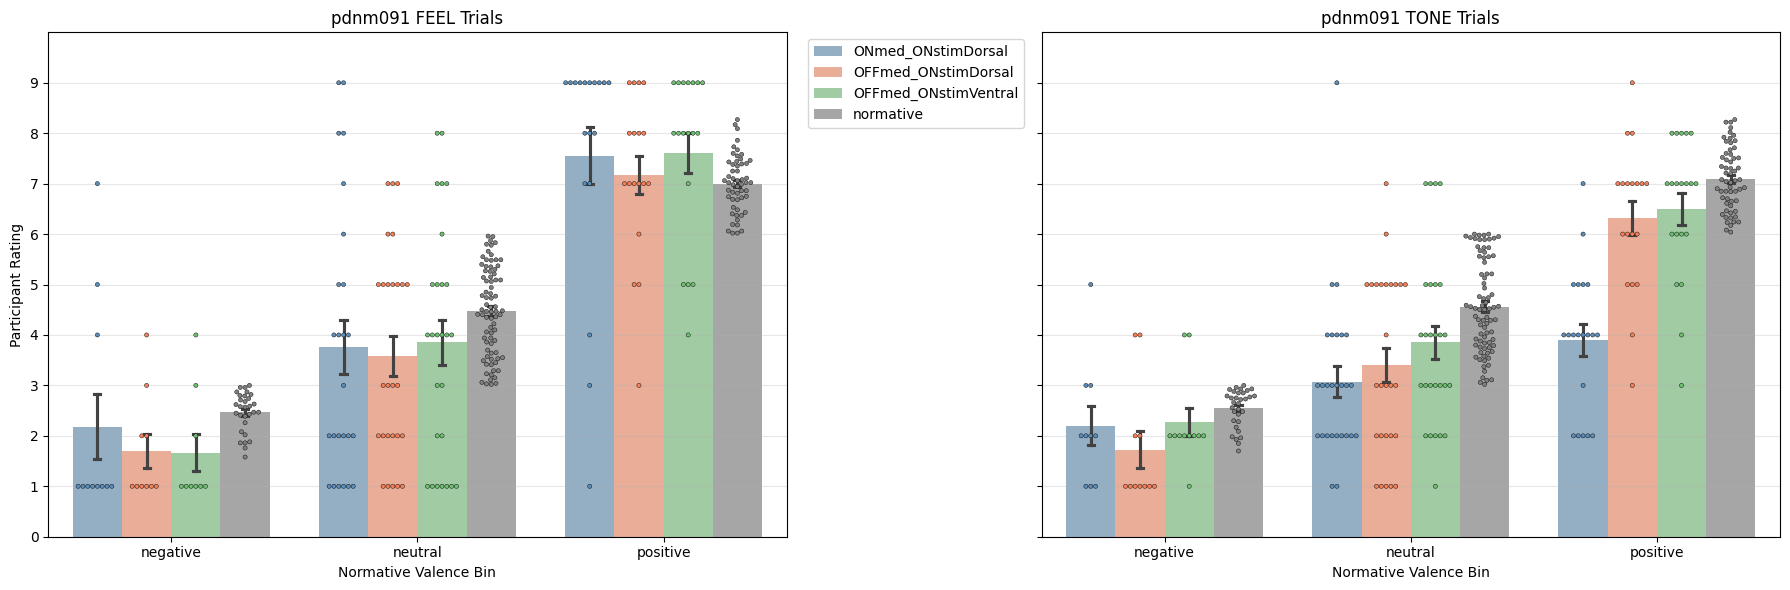

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

sns.barplot(
    data=feel_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[0]
)
sns.swarmplot(
    data=feel_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[0]
)
axes[0].set_title(f'{subj} FEEL Trials')
axes[0].set_xlabel('Normative Valence Bin')
axes[0].set_ylabel('Participant Rating')
axes[0].grid(True, axis='y', alpha=0.3)

sns.barplot(
    data=tone_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[1]
)
sns.swarmplot(
    data=tone_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[1]
)
axes[1].set_title(f'{subj} TONE Trials')
axes[1].set_xlabel('Normative Valence Bin')
axes[1].set_ylabel('')
axes[1].grid(True, axis='y', alpha=0.3)

axes[0].set_ylim(0, 10)
axes[0].set_yticks(np.arange(0, 10, 1))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(condition_order_with_norm)], labels[:len(condition_order_with_norm)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

In [24]:
# ---- FEEL: Wilcoxon tests including normative ----
feel_results_with_norm = []

for b in bin_labels:
    bin_df = feel_df_with_norm[feel_df_with_norm['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order_with_norm, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        feel_results_with_norm.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

feel_results_with_norm_df = pd.DataFrame(feel_results_with_norm)
feel_results_with_norm_df

,valence_bin,condition_1,condition_2,n1,n2,statistic,p_value,stars
0,negative,ONmed_ONstimDorsal,OFFmed_ONstimDorsal,11,10,-0.105627,0.915878,
1,negative,ONmed_ONstimDorsal,OFFmed_ONstimVentral,11,9,0.075974,0.939440,
2,negative,ONmed_ONstimDorsal,normative,11,30,-2.206837,0.027325,*
3,negative,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,10,9,0.163299,0.870283,
4,negative,OFFmed_ONstimDorsal,normative,10,30,-2.514398,0.011924,*
5,negative,OFFmed_ONstimVentral,normative,9,30,-2.350000,0.018773,*
6,neutral,ONmed_ONstimDorsal,OFFmed_ONstimDorsal,25,27,-0.146518,0.883513,
7,neutral,ONmed_ONstimDorsal,OFFmed_ONstimVentral,25,27,-0.247249,0.804716,
8,neutral,ONmed_ONstimDorsal,normative,25,79,-2.323933,0.020129,*
9,neutral,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,27,27,-0.216250,0.828793,


In [25]:
# ---- TONE: Wilcoxon tests including normative ----
tone_results_with_norm = []

for b in bin_labels:
    bin_df = tone_df_with_norm[tone_df_with_norm['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order_with_norm, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['participant_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['participant_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        tone_results_with_norm.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

tone_results_with_norm_df = pd.DataFrame(tone_results_with_norm)
tone_results_with_norm_df

,valence_bin,condition_1,condition_2,n1,n2,statistic,p_value,stars
0,negative,ONmed_ONstimDorsal,OFFmed_ONstimDorsal,10,11,1.161895,2.452781e-01,
1,negative,ONmed_ONstimDorsal,OFFmed_ONstimVentral,10,11,-0.316880,7.513343e-01,
2,negative,ONmed_ONstimDorsal,normative,10,32,-1.328905,1.838793e-01,
3,negative,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,11,11,-1.772955,7.623612e-02,
4,negative,OFFmed_ONstimDorsal,normative,11,32,-2.839181,4.522945e-03,**
5,negative,OFFmed_ONstimVentral,normative,11,32,-2.004128,4.505635e-02,*
6,neutral,ONmed_ONstimDorsal,OFFmed_ONstimDorsal,27,27,-0.804449,4.211378e-01,
7,neutral,ONmed_ONstimDorsal,OFFmed_ONstimVentral,27,27,-1.851097,6.415553e-02,
8,neutral,ONmed_ONstimDorsal,normative,27,81,-5.459610,4.771821e-08,***
9,neutral,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,27,27,-0.761199,4.465382e-01,


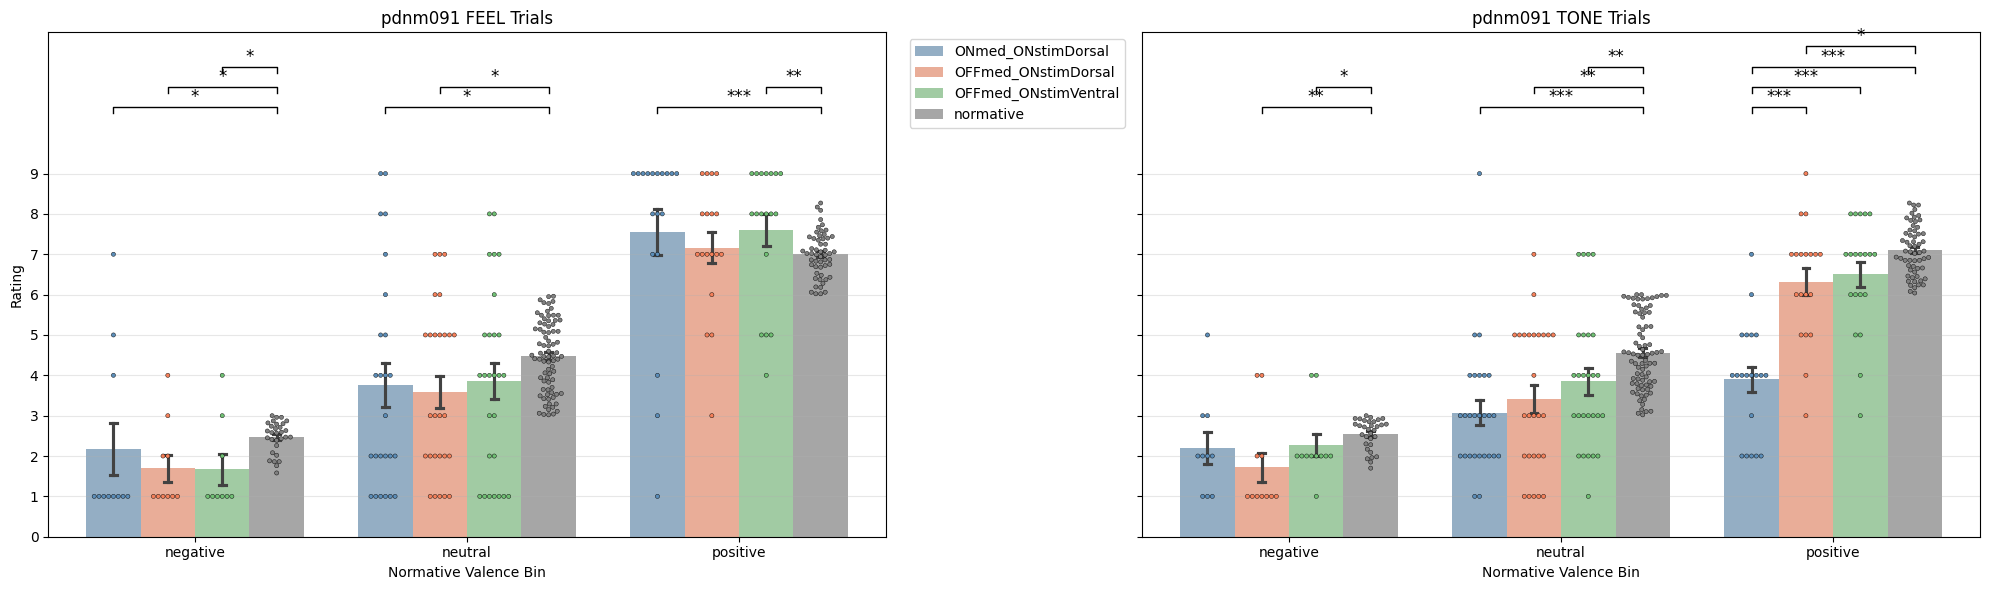

In [26]:
bar_width = 0.8 / len(condition_order_with_norm)
condition_offsets = {}
for i, cond in enumerate(condition_order_with_norm):
    condition_offsets[cond] = -0.4 + bar_width * (i + 0.5)

y_max = 10
bracket_height = y_max * 0.05

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# ---- FEEL ----
sns.barplot(
    data=feel_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[0]
)
sns.swarmplot(
    data=feel_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[0]
)

bin_bracket_count = {b: 0 for b in bin_labels}
for i in range(len(feel_results_with_norm_df)):
    row = feel_results_with_norm_df.iloc[i]
    if row['stars'] == '':
        continue

    bin_x = bin_labels.index(row['valence_bin'])
    x1 = bin_x + condition_offsets[row['condition_1']]
    x2 = bin_x + condition_offsets[row['condition_2']]

    level = bin_bracket_count[row['valence_bin']]
    y = y_max + bracket_height * (level + 1)
    bin_bracket_count[row['valence_bin']] += 1

    axes[0].plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y],
                 color='black', linewidth=1)
    axes[0].text((x1 + x2) / 2, y + bracket_height*0.35, row['stars'],
                 ha='center', va='bottom', fontsize=12)

axes[0].set_title(f'{subj} FEEL Trials')
axes[0].set_xlabel('Normative Valence Bin')
axes[0].set_ylabel('Rating')
axes[0].grid(True, axis='y', alpha=0.3)

# ---- TONE ----
sns.barplot(
    data=tone_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    errorbar='se', capsize=0.1, alpha=0.7, ax=axes[1]
)
sns.swarmplot(
    data=tone_df_with_norm, x='valence_bin', y='participant_rating', hue='condition',
    order=bin_labels, hue_order=condition_order_with_norm, palette=condition_colors_with_norm,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[1]
)

bin_bracket_count = {b: 0 for b in bin_labels}
for i in range(len(tone_results_with_norm_df)):
    row = tone_results_with_norm_df.iloc[i]
    if row['stars'] == '':
        continue

    bin_x = bin_labels.index(row['valence_bin'])
    x1 = bin_x + condition_offsets[row['condition_1']]
    x2 = bin_x + condition_offsets[row['condition_2']]

    level = bin_bracket_count[row['valence_bin']]
    y = y_max + bracket_height * (level + 1)
    bin_bracket_count[row['valence_bin']] += 1

    axes[1].plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y],
                 color='black', linewidth=1)
    axes[1].text((x1 + x2) / 2, y + bracket_height*0.35, row['stars'],
                 ha='center', va='bottom', fontsize=12)

axes[1].set_title(f'{subj} TONE Trials')
axes[1].set_xlabel('Normative Valence Bin')
axes[1].set_ylabel('')
axes[1].grid(True, axis='y', alpha=0.3)

axes[0].set_ylim(0, 12.5)
axes[0].set_yticks(np.arange(0, 10, 1))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(condition_order_with_norm)], labels[:len(condition_order_with_norm)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

In [27]:
instruction_results = []

for cond in condition_order:
    for b in bin_labels:
        sub_df = plot_df[(plot_df['condition'] == cond) & (plot_df['valence_bin'] == b)]

        vals_feel = sub_df[sub_df['instruction'] == 'FEEL']['participant_rating']
        vals_tone = sub_df[sub_df['instruction'] == 'TONE']['participant_rating']

        stat, p = ranksums(vals_feel, vals_tone)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        instruction_results.append({
            'condition': cond,
            'valence_bin': b,
            'n_feel': len(vals_feel),
            'n_tone': len(vals_tone),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

instruction_results_df = pd.DataFrame(instruction_results)
instruction_results_df

,condition,valence_bin,n_feel,n_tone,statistic,p_value,stars
0,ONmed_ONstimDorsal,negative,11,10,-1.021059,0.307226,
1,ONmed_ONstimDorsal,neutral,25,27,0.283878,0.776503,
2,ONmed_ONstimDorsal,positive,18,20,3.932143,0.000084,***
3,OFFmed_ONstimDorsal,negative,10,11,0.070418,0.943861,
4,OFFmed_ONstimDorsal,neutral,27,27,0.294100,0.768682,
5,OFFmed_ONstimDorsal,positive,18,19,1.838405,0.066003,
6,OFFmed_ONstimVentral,negative,9,11,-1.709409,0.087375,
7,OFFmed_ONstimVentral,neutral,27,27,-0.051900,0.958608,
8,OFFmed_ONstimVentral,positive,18,20,2.543468,0.010976,*


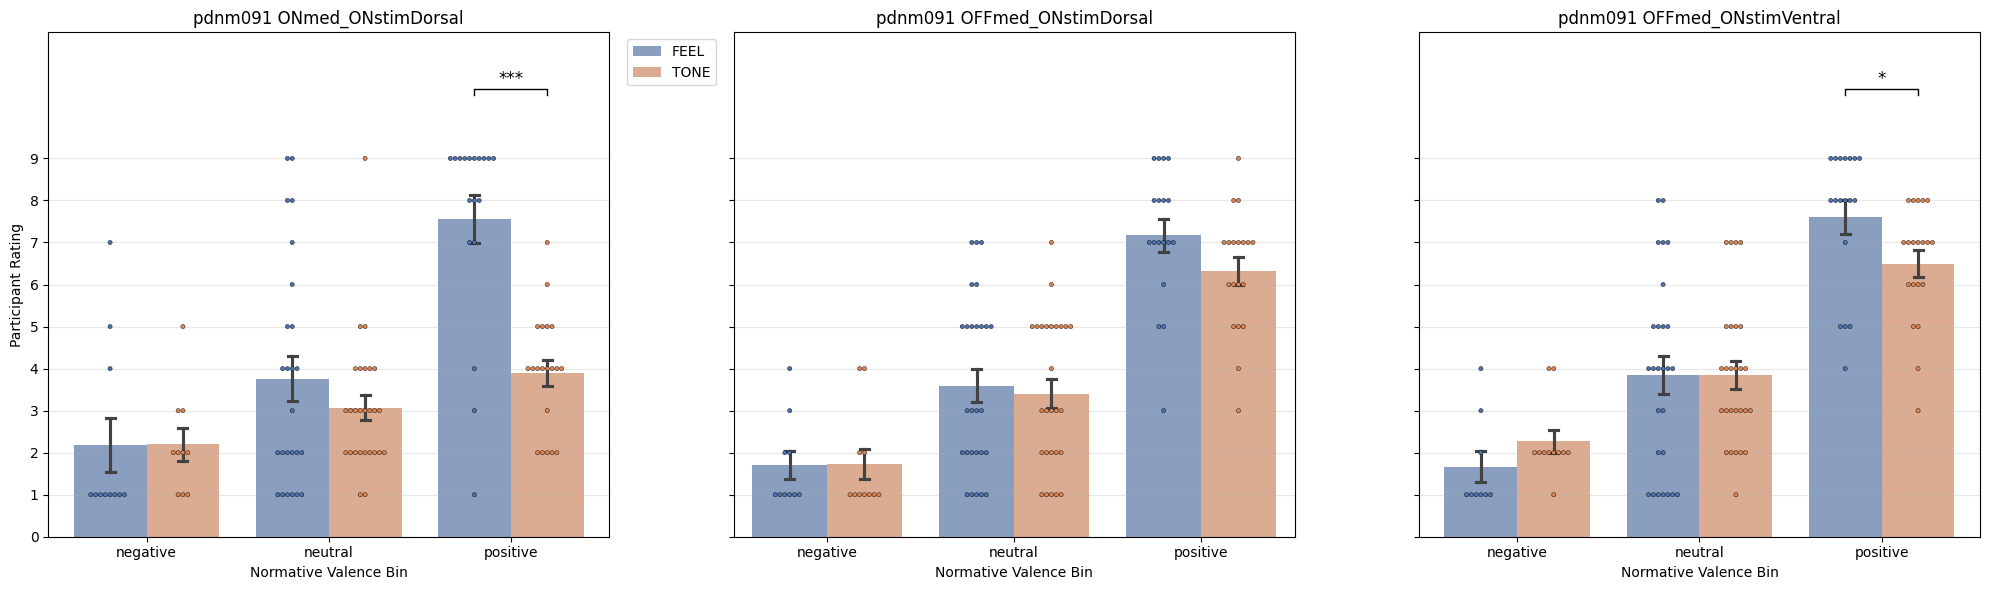

In [28]:
cue_colors = ['#4c72b0', '#dd8452']  # FEEL, TONE
cue_order = ['FEEL', 'TONE']

bar_width = 0.8 / len(cue_order)
cue_offsets = {}
for i, c in enumerate(cue_order):
    cue_offsets[c] = -0.4 + bar_width * (i + 0.5)

y_max = 10
bracket_height = y_max * 0.05

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for idx, cond in enumerate(condition_order):
    cond_df = plot_df[plot_df['condition'] == cond]

    sns.barplot(
        data=cond_df, x='valence_bin', y='participant_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        errorbar='se', capsize=0.1, alpha=0.7, ax=axes[idx]
    )
    sns.swarmplot(
        data=cond_df, x='valence_bin', y='participant_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[idx]
    )

    cond_results = instruction_results_df[instruction_results_df['condition'] == cond]

    for i in range(len(cond_results)):
        row = cond_results.iloc[i]
        if row['stars'] == '':
            continue

        bin_x = bin_labels.index(row['valence_bin'])
        x1 = bin_x + cue_offsets['FEEL']
        x2 = bin_x + cue_offsets['TONE']

        y = y_max + bracket_height

        axes[idx].plot([x1, x1, x2, x2], [y, y + bracket_height*0.3, y + bracket_height*0.3, y],
                        color='black', linewidth=1)
        axes[idx].text((x1 + x2) / 2, y + bracket_height*0.35, row['stars'],
                        ha='center', va='bottom', fontsize=12)

    axes[idx].set_title(f'{subj} {cond}')
    axes[idx].set_xlabel('Normative Valence Bin')
    axes[idx].set_ylabel('Participant Rating' if idx == 0 else '')
    axes[idx].grid(True, axis='y', alpha=0.3)

axes[0].set_ylim(0, 12)
axes[0].set_yticks(np.arange(0, 10, 1))

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(cue_order)], labels[:len(cue_order)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()
axes[2].get_legend().remove()

plt.tight_layout()
plt.show()

C:\Users\fkamdar\AppData\Local\Temp\ipykernel_11180\1061140995.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  feel_df['diff_rating'] = feel_df['participant_rating'] - feel_df['normative_rating']
C:\Users\fkamdar\AppData\Local\Temp\ipykernel_11180\1061140995.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tone_df['diff_rating'] = tone_df['participant_rating'] - tone_df['normative_rating']


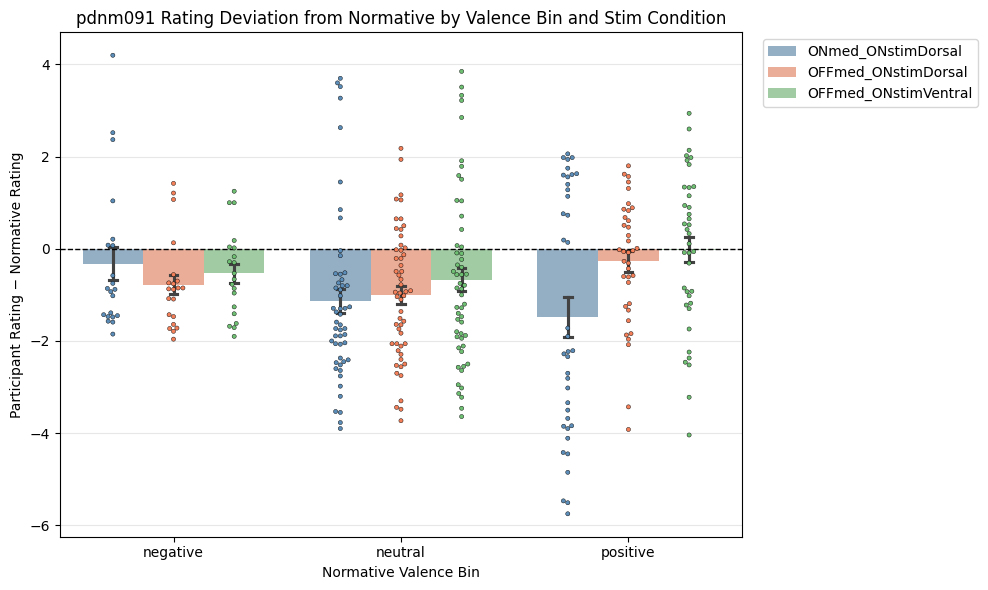

In [29]:
# Difference score: participant rating minus normative rating for each trial
plot_df['diff_rating'] = plot_df['participant_rating'] - plot_df['normative_rating']
feel_df['diff_rating'] = feel_df['participant_rating'] - feel_df['normative_rating']
tone_df['diff_rating'] = tone_df['participant_rating'] - tone_df['normative_rating']

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_df, x='valence_bin', y='diff_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    errorbar='se', capsize=0.1, alpha=0.7, ax=ax
)
sns.swarmplot(
    data=plot_df, x='valence_bin', y='diff_rating', hue='condition',
    order=bin_labels, hue_order=condition_order, palette=condition_colors,
    dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=ax
)

ax.axhline(0, color='black', linewidth=1, linestyle='--')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)],
          loc='upper left', bbox_to_anchor=(1.02, 1))

ax.set_xlabel('Normative Valence Bin')
ax.set_ylabel('Participant Rating − Normative Rating')
ax.set_title(f'{subj} Rating Deviation from Normative by Valence Bin and Stim Condition')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
diff_results = []

for b in bin_labels:
    bin_df = plot_df[plot_df['valence_bin'] == b]

    for cond1, cond2 in combinations(condition_order, 2):
        vals1 = bin_df[bin_df['condition'] == cond1]['diff_rating']
        vals2 = bin_df[bin_df['condition'] == cond2]['diff_rating']

        stat, p = ranksums(vals1, vals2)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        diff_results.append({
            'valence_bin': b,
            'condition_1': cond1,
            'condition_2': cond2,
            'n1': len(vals1),
            'n2': len(vals2),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

diff_results_df = pd.DataFrame(diff_results)
diff_results_df

,valence_bin,condition_1,condition_2,n1,n2,statistic,p_value,stars
0,negative,ONmed_ONstimDorsal,OFFmed_ONstimDorsal,21,21,0.553426,0.579972,
1,negative,ONmed_ONstimDorsal,OFFmed_ONstimVentral,21,20,-0.143451,0.885934,
2,negative,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,21,20,-1.121527,0.262064,
3,neutral,ONmed_ONstimDorsal,OFFmed_ONstimDorsal,52,54,-1.222872,0.221378,
4,neutral,ONmed_ONstimDorsal,OFFmed_ONstimVentral,52,54,-1.554660,0.120027,
5,neutral,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,54,54,-0.476196,0.633935,
6,positive,ONmed_ONstimDorsal,OFFmed_ONstimDorsal,38,37,-1.589580,0.111929,
7,positive,ONmed_ONstimDorsal,OFFmed_ONstimVentral,38,38,-2.202407,0.027637,*
8,positive,OFFmed_ONstimDorsal,OFFmed_ONstimVentral,37,38,-0.821283,0.411485,


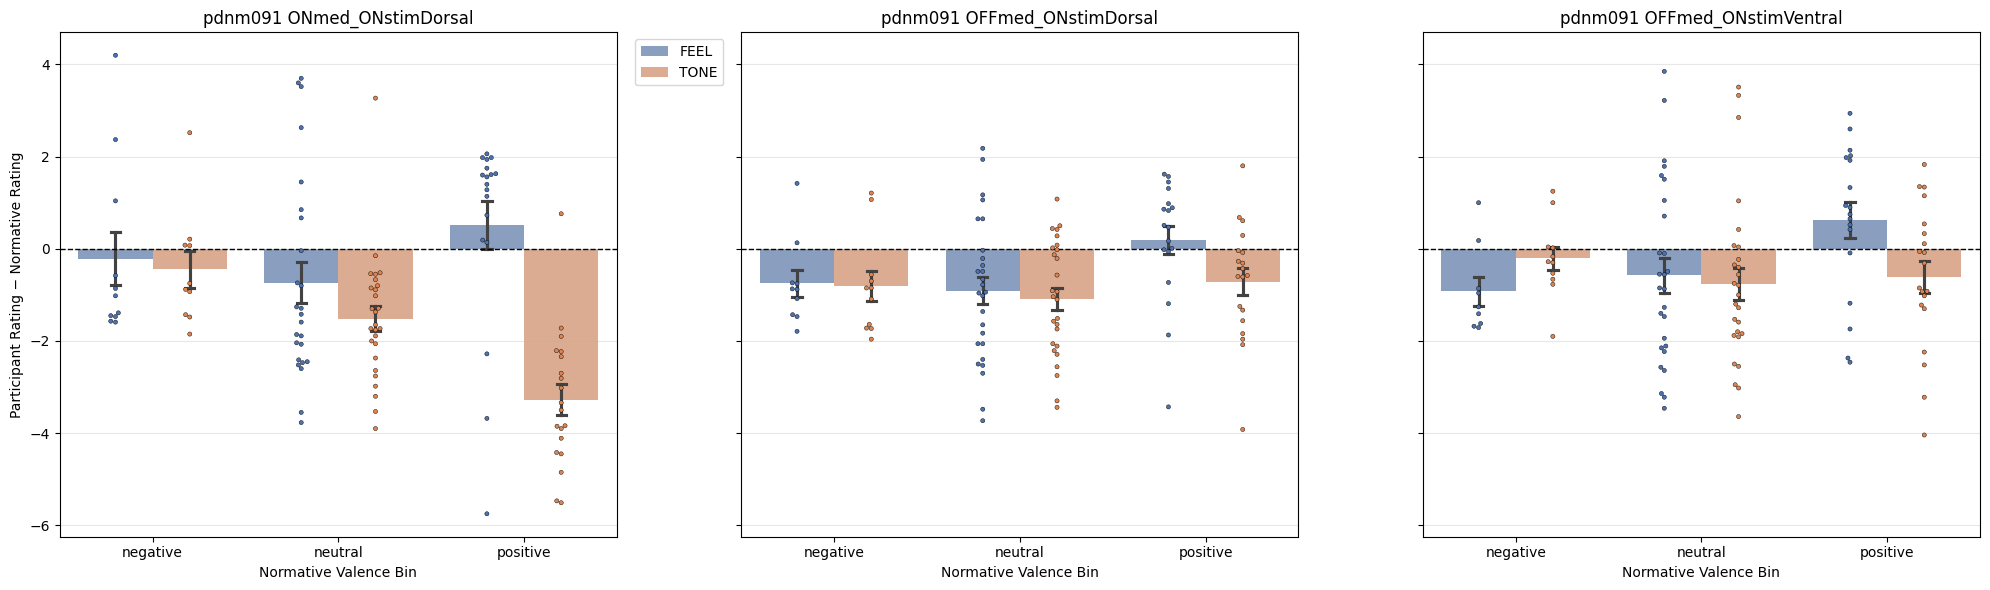

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for idx, cond in enumerate(condition_order):
    cond_df = plot_df[plot_df['condition'] == cond]

    sns.barplot(
        data=cond_df, x='valence_bin', y='diff_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        errorbar='se', capsize=0.1, alpha=0.7, ax=axes[idx]
    )
    sns.swarmplot(
        data=cond_df, x='valence_bin', y='diff_rating', hue='instruction',
        order=bin_labels, hue_order=cue_order, palette=cue_colors,
        dodge=True, size=3, edgecolor='black', linewidth=0.3, ax=axes[idx]
    )

    axes[idx].axhline(0, color='black', linewidth=1, linestyle='--')

    axes[idx].set_title(f'{subj} {cond}')
    axes[idx].set_xlabel('Normative Valence Bin')
    axes[idx].set_ylabel('Participant Rating − Normative Rating' if idx == 0 else '')
    axes[idx].grid(True, axis='y', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:len(cue_order)], labels[:len(cue_order)],
               loc='upper left', bbox_to_anchor=(1.02, 1))
axes[1].get_legend().remove()
axes[2].get_legend().remove()

plt.tight_layout()
plt.show()

In [32]:
diff_instruction_results = []

for cond in condition_order:
    for b in bin_labels:
        sub_df = plot_df[(plot_df['condition'] == cond) & (plot_df['valence_bin'] == b)]

        vals_feel = sub_df[sub_df['instruction'] == 'FEEL']['diff_rating']
        vals_tone = sub_df[sub_df['instruction'] == 'TONE']['diff_rating']

        stat, p = ranksums(vals_feel, vals_tone)

        if p < 0.001:
            stars = '***'
        elif p < 0.01:
            stars = '**'
        elif p < 0.05:
            stars = '*'
        else:
            stars = ''

        diff_instruction_results.append({
            'condition': cond,
            'valence_bin': b,
            'n_feel': len(vals_feel),
            'n_tone': len(vals_tone),
            'statistic': stat,
            'p_value': p,
            'stars': stars
        })

diff_instruction_results_df = pd.DataFrame(diff_instruction_results)
diff_instruction_results_df

,condition,valence_bin,n_feel,n_tone,statistic,p_value,stars
0,ONmed_ONstimDorsal,negative,11,10,-0.281672,0.778195,
1,ONmed_ONstimDorsal,neutral,25,27,0.778377,0.436347,
2,ONmed_ONstimDorsal,positive,18,20,4.122173,0.000038,***
3,OFFmed_ONstimDorsal,negative,10,11,0.211254,0.832689,
4,OFFmed_ONstimDorsal,neutral,27,27,0.268150,0.788584,
5,OFFmed_ONstimDorsal,positive,18,19,2.491722,0.012713,*
6,OFFmed_ONstimVentral,negative,9,11,-1.823369,0.068247,
7,OFFmed_ONstimVentral,neutral,27,27,0.207600,0.835542,
8,OFFmed_ONstimVentral,positive,18,20,2.280351,0.022587,*


In [ ]:
from pymer4.models import Lmer


In [ ]:
import statsmodels.formula.api as smf


In [ ]:

# Fit the mixed effects model, R-style formula
model = Lmer(
    "participant_rating ~ normative_rating + condition + (1 | ImageIndex)",
    data=plot_df
)

results = model.fit()
print(results)

In [ ]:
model = smf.mixedlm(
    "participant_rating ~ normative_rating + condition",
    data=plot_df,
    groups=plot_df["ImageIndex"]
)

results = model.fit()
print(results.summary())